### Import necessary libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pickle

# Read in data

### Decide if splitting sets or not

In [2]:
split = True # rest in between sets negates fatigue, if present

if split:
    raw_df = pd.read_csv("/home/abbie/projects/TECH646-Haptic-Results/data/raw_data_split.csv")
    raw_df.set_index('subject_trial', inplace=True)
else:
    raw_df = pd.read_csv("/home/abbie/projects/TECH646-Haptic-Results/data/raw_data.csv")
    raw_df.set_index('subject', inplace=True)

### Decide for all or only small

In [3]:
small_only = True # switching up between big and small created inconsistency

if small_only:
    raw_df = raw_df.drop(raw_df.filter(like='big', axis=1), axis=1)

print(raw_df.shape[1])

15


### Plot all the raw data

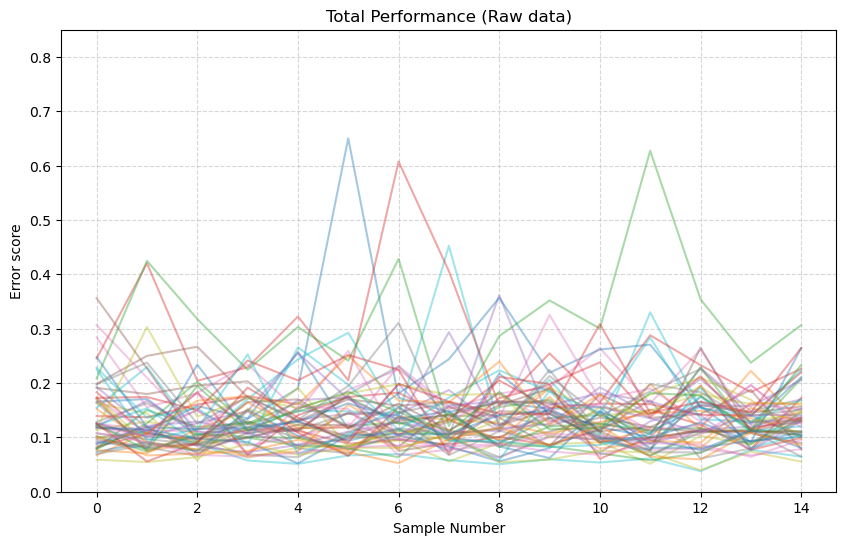

In [4]:
plt.figure(figsize=(10, 6))
for i, row in raw_df.iterrows():
    plt.plot(range(0, raw_df.shape[1]), row.values, alpha=0.4)  # faint line for each subject

plt.title("Total Performance (Raw data)")
plt.xlabel("Sample Number")
plt.ylabel("Error score")
plt.ylim(0, 0.85)
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()

### Clean up the data by removing outliers

In [5]:
# can allow for more outliers for low performance - less difficult to determine
std_dev = 3 # how many standard deviations from the mean data can be

# calculate z scores
z_scores = (raw_df - raw_df.mean()) / raw_df.std()

# replace values with NaN if they’re more than determined standard deviations from the mean
df_clean = raw_df.mask(np.abs(z_scores) > std_dev)

# fill NaN with the median of that column instead of dropping
df_clean = df_clean.apply(lambda x: x.fillna(x.median()), axis=0)

#### Visualize cleaned up data

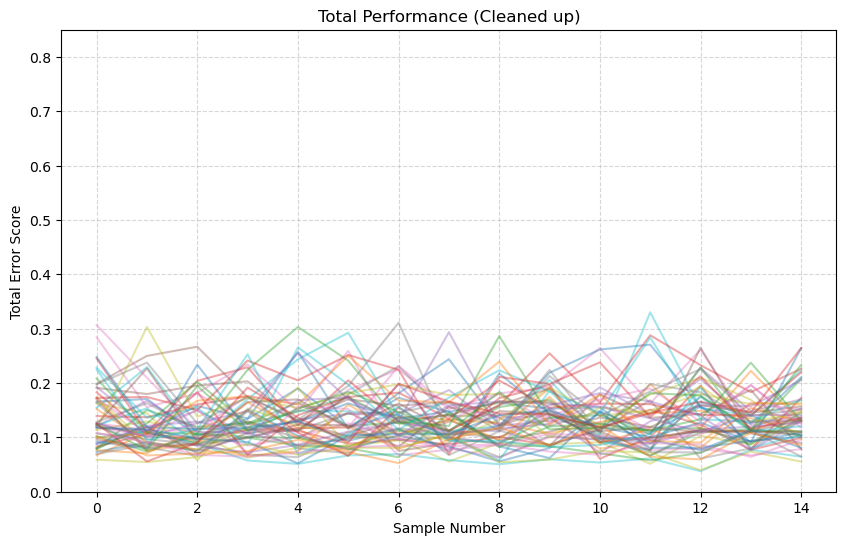

In [6]:
plt.figure(figsize=(10, 6))
for i, row in df_clean.iterrows():
    plt.plot(range(0, raw_df.shape[1]), row.values, alpha=0.4)  # faint line for each subject

plt.title("Total Performance (Cleaned up)")
plt.xlabel("Sample Number")
plt.ylabel("Total Error Score")
plt.ylim(0, 0.85)
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()

# Determine percentage change at various window sizes

## Make function to calculate the change

In [7]:
def get_change(start, end):
    difference = end - start
    change = difference / start
    percent_change = change * 100
    return percent_change

## Calculate each percentage change

In [8]:
if not small_only:
    window_sizes = [4, 8, 12, 16, 20]
else:
    window_sizes = [3, 6, 9, 12, 15] # good balance of short and long term

percent_dict = {}

for window in window_sizes:
    all_percents = []
    for i, row in df_clean.iterrows():
        errors = row.values
        for start in range(len(errors) - window + 1):
            start_val = errors[start]

            end_val = errors[start + window - 1]

            all_percents.append(get_change(start_val, end_val))

    percent_dict[window] = np.array(all_percents)

### Plot each percentage change

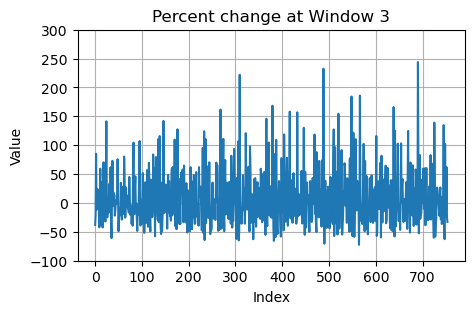

Number of percent samples: 754


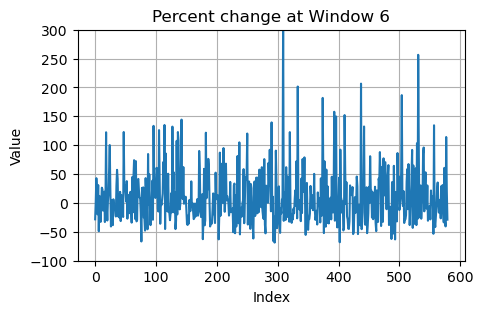

Number of percent samples: 580


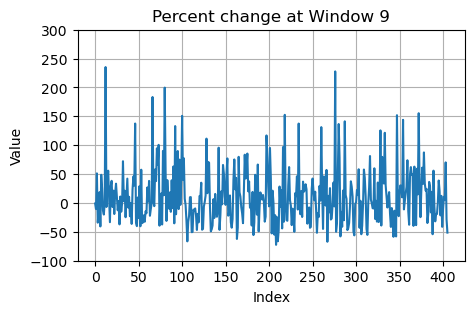

Number of percent samples: 406


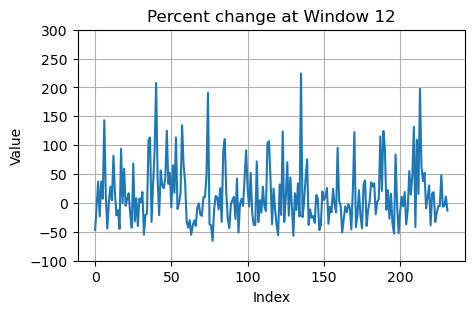

Number of percent samples: 232


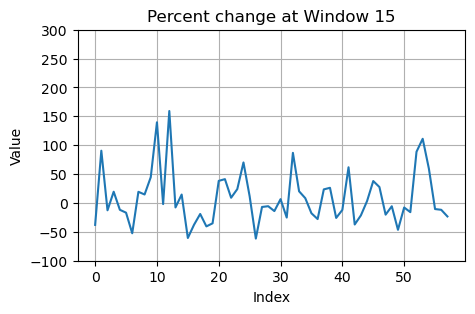

Number of percent samples: 58


In [9]:
for window, percent in percent_dict.items():
    plt.figure(figsize=(5, 3))
    plt.plot(range(len(percent)), percent)
    plt.title(f'Percent change at Window {window}')
    plt.xlabel('Index')
    plt.ylabel('Value')
    plt.ylim(-100, 300)
    plt.grid(True)
    plt.show()
    print("Number of percent samples:", len(percent))

### Clean up and remove outliers

In [10]:
# can allow for more outliers for low performance - less difficult to determine
std_dev = 3  # how many standard deviations from the mean data can be

# replace outliers with median for each window
percent_dict_cleaned = {}

for window, percents in percent_dict.items():
    # calculate z-scores
    mean = np.nanmean(percents)
    std = np.nanstd(percents)
    z_scores = (percents - mean) / std
    
    # replace values with NaN if they're more than std_dev standard deviations from mean
    percents_masked = np.where(np.abs(z_scores) > std_dev, np.nan, percents)
    
    # fill NaN with the median
    median = np.nanmedian(percents_masked)
    percents_cleaned = np.where(np.isnan(percents_masked), median, percents_masked)
    
    percent_dict_cleaned[window] = percents_cleaned
    
    # print replacement statistics
    n_replaced = np.sum(np.abs(z_scores) > std_dev)
    pct_replaced = 100 * n_replaced / len(percents)
    print(f"Window {window}: Replaced {n_replaced} outliers ({pct_replaced:.1f}%) with median {median:.4f}")

# use cleaned data for downstream analysis
percent_dict = percent_dict_cleaned

Window 3: Replaced 11 outliers (1.5%) with median 0.4741
Window 6: Replaced 7 outliers (1.2%) with median -0.1307
Window 9: Replaced 4 outliers (1.0%) with median 3.7521
Window 12: Replaced 4 outliers (1.7%) with median 1.4699
Window 15: Replaced 1 outliers (1.7%) with median -5.6911


#### Plot cleaned up percent changes

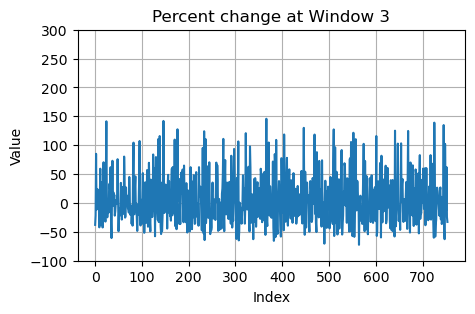

Number of percent samples: 754


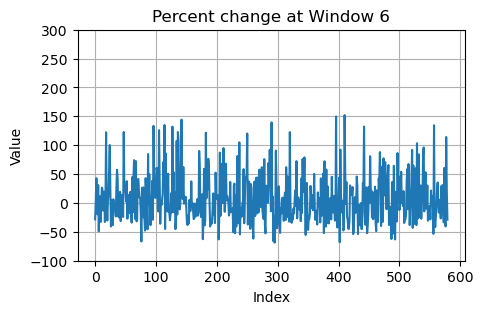

Number of percent samples: 580


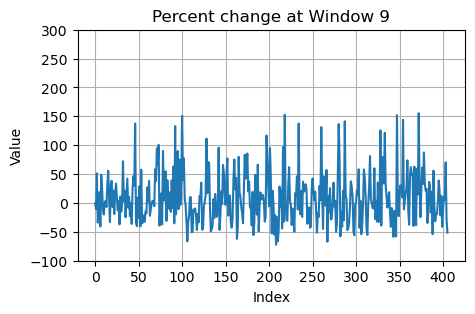

Number of percent samples: 406


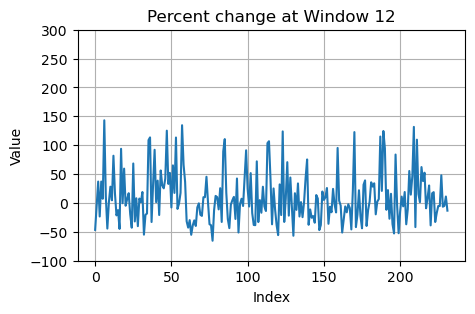

Number of percent samples: 232


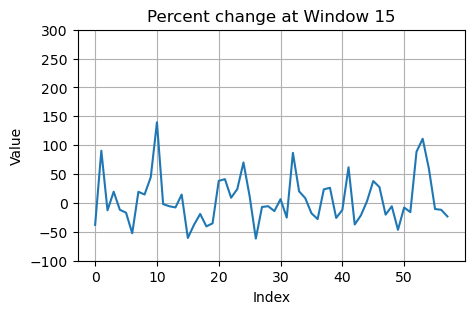

Number of percent samples: 58


In [11]:
for window, percent in percent_dict.items():
    plt.figure(figsize=(5, 3))
    plt.plot(range(len(percent)), percent)
    plt.title(f'Percent change at Window {window}')
    plt.xlabel('Index')
    plt.ylabel('Value')
    plt.ylim(-100, 300)
    plt.grid(True)
    plt.show()
    print("Number of percent samples:", len(percent))

# Detect inconsistency

## Calculate variance at every window and get thresholds

In [12]:
if not small_only:
    window_sizes = [4, 8, 12, 16, 20]
else:
    window_sizes = [3, 6, 9, 15] # good balance of short and long term

variance_dict = {}
thresholds = {}
desired_percentile = 90

for window in window_sizes:
    all_variances = []
    for i, row in df_clean.iterrows():
        errors = row.values
        for start in range(len(errors) - window + 1):
            window_vals = errors[start:start + window]
            var = np.var(window_vals, ddof=1)
            all_variances.append(var)

    variance_dict[window] = np.array(all_variances)


    threshold = np.percentile(all_variances, desired_percentile)
    thresholds[window] = threshold
    print(f"Window {window}: {str(desired_percentile)}th percentile variance cutoff = {threshold:.4f}")

Window 3: 90th percentile variance cutoff = 0.0042
Window 6: 90th percentile variance cutoff = 0.0038
Window 9: 90th percentile variance cutoff = 0.0035
Window 15: 90th percentile variance cutoff = 0.0031


# Export

In [13]:
with open('consistency_thresholds.pkl', 'wb') as f:
    pickle.dump(thresholds, f)